In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy
from eval_SA_atTime_v2 import *
from sampleMu import *

cols = nx = 51
lines = ny = 51

lx = 142.245
ly = 142.245
lz = 10

porosity = 0.2

def plot_vtk_data_2D(filename, plot_id):
    # Plot data
    # plt.style.use(plot_style)

    # load a vtk file as input
    reader = vtk.vtkXMLUnstructuredGridReader()
    reader.SetFileName(filename)
    reader.Update()
    data = reader.GetOutput()
    # print(data)

    # Read the field data and convert to numpy array
    nodes = vtk_to_numpy(data.GetPoints().GetData())
    x, y, z = nodes[:,0], nodes[:,1], nodes[:,2]

    # Campo
    field = vtk_to_numpy(data.GetPointData().GetArray(plot_id))
    field = field[::4]
    field = field.reshape((ny,nx))

    return field

In [17]:
# path_fossil = '/home/lamap/source/FOSSIL/build/dsc/FOSSIL_vs_openFOAM/output_fossil_sw1/'
path_openFOAM = '.'

data_dict = parse_openfoam_case(path_openFOAM, variables=['p','Sb','Fb','Ua','Ub'])

ti = 0
tf = 5e8
write_interval = 1e5
t = np.linspace(ti,tf,int(tf/write_interval))
time_steps = len(t)
# time_steps = len(data_dict['Sb'])

for i in data_dict.index:
    data_dict.rename(index={i: int(i/write_interval)}, inplace=True)

<Figure size 432x288 with 0 Axes>

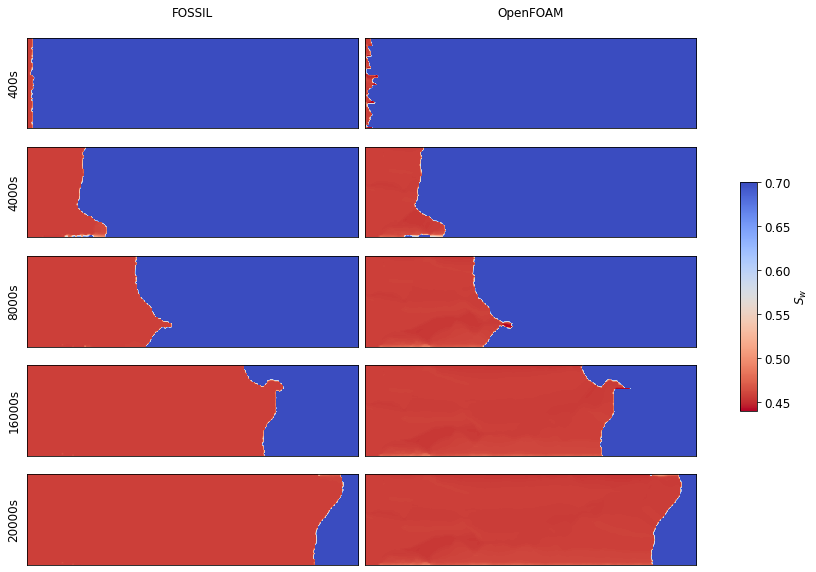

<Figure size 432x288 with 0 Axes>

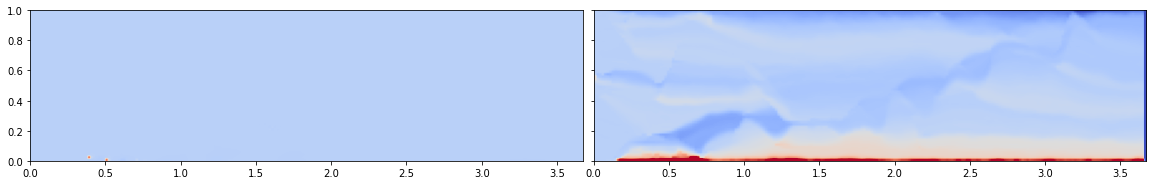

In [18]:
# PLOTS SATURAÇÃO

instants = [1, 10, 20, 40, 50]

sats_OF = data_dict['Sb']

colunas = ["FOSSIL", "OpenFOAM"]
plt.clf()
fig, axs = plt.subplots(len(instants), 2, sharex=True, sharey=True, figsize=(12, 10))
fig.subplots_adjust(hspace=0.02, wspace=0.02)
for i, inst in enumerate(instants):

    sat_FOSSIL = plot_vtk_data_2D(path_fossil+f"output/volume_vars_{inst:04}.vtu", 1)
    sat_OF = np.reshape(sats_OF[inst], (ny, nx))
    
    im0 = axs[i, 0].imshow(sat_FOSSIL, cmap='coolwarm_r', origin='lower', vmin=0.44, vmax=0.7, extent=[0., 3.67, 0, 1])
    axs[i, 0].set_xticks([])
    axs[i, 0].set_yticks([])

    im1 = axs[i, 1].imshow(sat_OF, cmap='coolwarm_r', origin='lower', vmin=0.44, vmax=0.7, extent=[0., 3.67, 0, 1])
    axs[i, 1].set_xticks([])
    axs[i, 1].set_yticks([])

    axs[i, 0].text(-0.02, 0.5, f'{inst * write_interval}s', va='center', ha='right', rotation=90, transform=axs[i, 0].transAxes, fontsize=12)


# Adicionando rótulos de coluna no topo de cada coluna
for j, col_label in enumerate(colunas):
    axs[0, j].text(0.5, 1.2, col_label, va='bottom', ha='center', transform=axs[0, j].transAxes, fontsize=12)

# Configura o espaço e a posição da colorbar ao lado direito da figura
cbar_ax = fig.add_axes([0.95, 0.35, 0.02, 0.318])  # Ajuste conforme necessário
fig.colorbar(im0, cax=cbar_ax, label='$S_w$')
cbar_ax.yaxis.label.set_size(12)  # Ajusta o tamanho da fonte do rótulo da colorbar
cbar_ax.tick_params(labelsize=12) 

plt.show()
plt.close()


plt.clf()
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(20, 5))
fig.subplots_adjust(hspace=0.02, wspace=0.02)
sat_FOSSIL = plot_vtk_data_2D(path_fossil+f"output/volume_vars_0100.vtu", 1)
sat_OF = np.reshape(sats_OF[99], (ny, nx))

im0 = axs[0].imshow(sat_FOSSIL, cmap='coolwarm', origin='lower', vmin=0.45, vmax=0.47, extent=[0., 3.67, 0, 1])

im1 = axs[1].imshow(sat_OF, cmap='coolwarm', origin='lower', vmin=0.45, vmax=0.47, extent=[0., 3.67, 0, 1])

fig.colorbar(im0, cax=cbar_ax, label='$S_w$')

plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

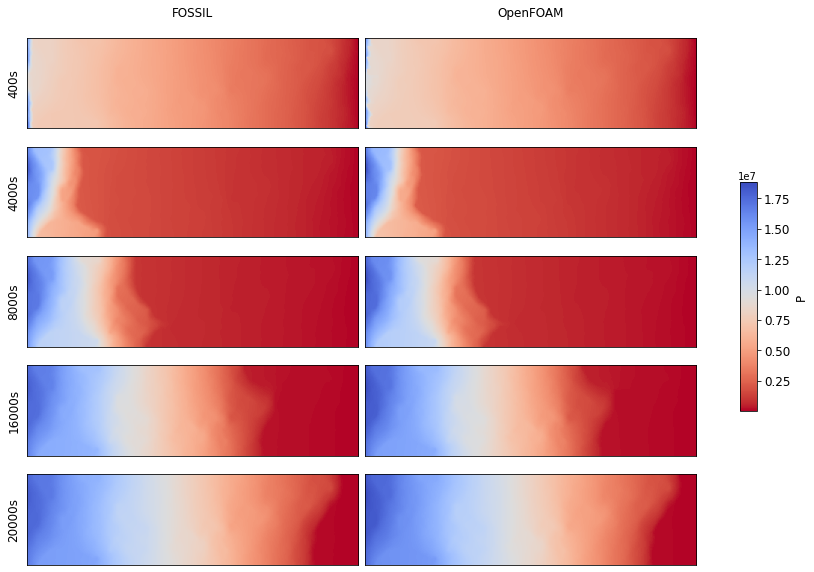

<Figure size 432x288 with 0 Axes>

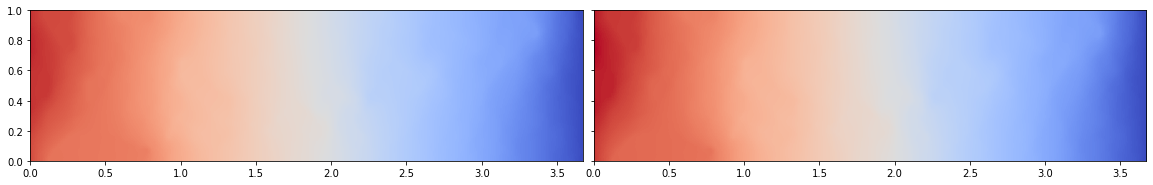

In [19]:
# PLOTS CAMPOS DE PRESSÃO
pressures_OF = data_dict['p']

colunas = ["FOSSIL", "OpenFOAM"]
plt.clf()
fig, axs = plt.subplots(len(instants), 2, sharex=True, sharey=True, figsize=(12, 10))
fig.subplots_adjust(hspace=0.02, wspace=0.02)
for i, inst in enumerate(instants):

    pres_FOSSIL = plot_vtk_data_2D(path_fossil+f"output/volume_vars_{inst:04}.vtu", 15)
    pres_OF = np.reshape(pressures_OF[inst], (ny, nx))

    min_p, max_p = np.min(pres_OF), np.max(pres_OF)

    im0 = axs[i, 0].imshow(pres_FOSSIL, cmap='coolwarm_r', origin='lower', vmin=min_p, vmax=max_p, extent=[0., 3.67, 0, 1])
    axs[i, 0].set_xticks([])
    axs[i, 0].set_yticks([])
    im1 = axs[i, 1].imshow(pres_OF, cmap='coolwarm_r', origin='lower', vmin=min_p, vmax=max_p, extent=[0., 3.67, 0, 1])
    axs[i, 1].set_xticks([])
    axs[i, 1].set_yticks([])

    axs[i, 0].text(-0.02, 0.5, f'{inst * write_interval}s', va='center', ha='right', rotation=90, transform=axs[i, 0].transAxes, fontsize=12)

# Adicionando rótulos de coluna no topo de cada coluna
for j, col_label in enumerate(colunas):
    axs[0, j].text(0.5, 1.2, col_label, va='bottom', ha='center', transform=axs[0, j].transAxes, fontsize=12)

# Configura o espaço e a posição da colorbar ao lado direito da figura
cbar_ax = fig.add_axes([0.95, 0.35, 0.02, 0.318])  # Ajuste conforme necessário
fig.colorbar(im0, cax=cbar_ax, label='P')
cbar_ax.yaxis.label.set_size(12)  # Ajusta o tamanho da fonte do rótulo da colorbar
cbar_ax.tick_params(labelsize=12) 
plt.show()
plt.close()


plt.clf()
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(20, 5))
fig.subplots_adjust(hspace=0.02, wspace=0.02)
pres_FOSSIL = plot_vtk_data_2D(path_fossil+f"output/volume_vars_0096.vtu", 15)
pres_OF = np.reshape(pressures_OF[96], (ny, nx))
min_p, max_p = np.min(pres_OF), np.max(pres_OF)
im0 = axs[0].imshow(pres_FOSSIL, cmap='coolwarm', origin='lower', vmin=min_p, vmax=max_p, extent=[0., 3.67, 0, 1])
im1 = axs[1].imshow(pres_OF, cmap='coolwarm', origin='lower', vmin=min_p, vmax=max_p, extent=[0., 3.67, 0, 1])
fig.colorbar(im0, cax=cbar_ax, label='P')
plt.show()
plt.close()

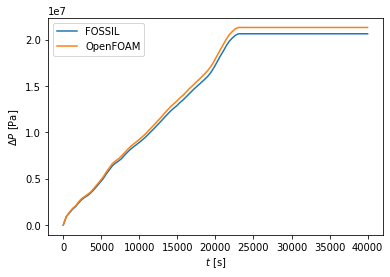

20618462.0 21302370.511633333
0.0319950419944498


In [22]:
# PLOTS PRESSURE DROP

def calculate_dp_field(ff):
    ff = np.reshape(ff, (ny, nx))
    return np.mean(ff[:, 0]) - np.mean(ff[:, -1])

pressures_OF = data_dict['p']
dp_OF = []
dp_OF.append(0)
for i in range(1, len(pressures_OF)):
    dp_OF.append(calculate_dp_field(pressures_OF[i]))

dp_fossil = []
dp_fossil.append(0)
for i in range(1, len(t)):
    pres_FOSSIL = plot_vtk_data_2D(path_fossil+f"output/volume_vars_{i:04}.vtu", 15)
    dp_fossil.append(calculate_dp_field(pres_FOSSIL))

plt.plot(t, dp_fossil, label='FOSSIL')
plt.plot(t, dp_OF, label='OpenFOAM')
plt.legend(loc='best')
plt.xticks(np.arange(0, 40001, step=5000))
plt.ylabel('$\Delta P$ [Pa]')
plt.xlabel('$t$ [s]')
plt.show()

print(max(dp_fossil), max(dp_OF))

print(abs(np.array(dp_fossil[-1])-np.array(dp_OF[-1]))/(np.array(dp_OF[-1])))

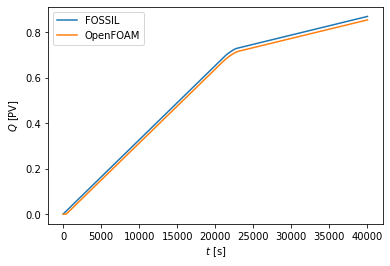

In [21]:
# PLOTS PRODUÇÃO

# integrate in time the extracted water flow rate to obtain the cumulative water production
prod_w = np.zeros(time_steps)
get = -2
aux_df = data_dict.copy()
aux_df['Ub'] = aux_df['Ub'].apply(lambda x : np.sum(x.reshape(ny, nx, 3)[:, get,0]) )
for j in range(1, time_steps):
    prod_w[j] = np.trapz(aux_df['Ub'].iloc[:j], dx=write_interval)

prod_w /= (lx*ny*porosity)

plt.clf()
t_fossil = pd.read_csv(path_fossil+f'production.csv').to_numpy()[:,0]
plt.plot(t_fossil, pd.read_csv(path_fossil+f'production.csv').to_numpy()[:,6], label='FOSSIL')
plt.plot(t, prod_w, label='OpenFOAM')
plt.legend(loc='best')
plt.xticks(np.arange(0, 40001, step=5000))
plt.ylabel('$Q$ [PV]')
plt.xlabel('$t$ [s]')
plt.show()